<a href="https://colab.research.google.com/github/Aysha2004/S7_INTERNSHIP/blob/main/S7_Internship_d5_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import zipfile
import os
import pandas as pd

zip_path = "/content/archive_text.zip"
extract_path = "extracted_files"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

csv_data = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_path = os.path.join(root, file)

            df = pd.read_csv(csv_path)
            csv_data.append(df)

            print(f"Loaded: {file}")
            print(df.head())  # First 5 rows

print("Total CSV files loaded:", len(csv_data))

Loaded: final_dataset.csv
                                                text     emotion
0  i feel rather funny ending with so many dupes ...         fun
1                     i feel surprised by the result    surprise
2                    i am officially feeling festive     neutral
3  i suddenly found myself standing before this w...    surprise
4  i look at the meager pile of food i purchased ...  enthusiasm
Total CSV files loaded: 1


In [10]:
df.head()

,text,emotion
0,i feel rather funny ending with so many dupes ...,fun
1,i feel surprised by the result,surprise
2,i am officially feeling festive,neutral
3,i suddenly found myself standing before this w...,surprise
4,i look at the meager pile of food i purchased ...,enthusiasm


In [12]:
df["lowercase_text"] = df["text"].str.lower()

print(df[["text", "lowercase_text"]].head())

                                                text  \
0  i feel rather funny ending with so many dupes ...   
1                     i feel surprised by the result   
2                    i am officially feeling festive   
3  i suddenly found myself standing before this w...   
4  i look at the meager pile of food i purchased ...   

                                      lowercase_text  
0  i feel rather funny ending with so many dupes ...  
1                     i feel surprised by the result  
2                    i am officially feeling festive  
3  i suddenly found myself standing before this w...  
4  i look at the meager pile of food i purchased ...  


In [15]:
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt_tab')

df["tokens"] = df["lowercase_text"].apply(word_tokenize)

print(df[["lowercase_text", "tokens"]].head())

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


                                      lowercase_text  \
0  i feel rather funny ending with so many dupes ...   
1                     i feel surprised by the result   
2                    i am officially feeling festive   
3  i suddenly found myself standing before this w...   
4  i look at the meager pile of food i purchased ...   

                                              tokens  
0  [i, feel, rather, funny, ending, with, so, man...  
1              [i, feel, surprised, by, the, result]  
2              [i, am, officially, feeling, festive]  
3  [i, suddenly, found, myself, standing, before,...  
4  [i, look, at, the, meager, pile, of, food, i, ...  


In [18]:
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

df["tokens_no_stopwords"] = df["tokens"].apply(lambda words: [word for word in words if word not in stop_words])

print(df[["tokens", "tokens_no_stopwords"]].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                              tokens  \
0  [i, feel, rather, funny, ending, with, so, man...   
1              [i, feel, surprised, by, the, result]   
2              [i, am, officially, feeling, festive]   
3  [i, suddenly, found, myself, standing, before,...   
4  [i, look, at, the, meager, pile, of, food, i, ...   

                                 tokens_no_stopwords  
0  [feel, rather, funny, ending, many, dupes, alw...  
1                          [feel, surprised, result]  
2                     [officially, feeling, festive]  
3  [suddenly, found, standing, woman, dressed, li...  
4  [look, meager, pile, food, purchased, week, fe...  


In [21]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

df["stemmed_tokens"] = df["tokens_no_stopwords"].apply(lambda words: [stemmer.stem(word) for word in words])

print(df[["tokens_no_stopwords", "stemmed_tokens"]].head(10))

                                 tokens_no_stopwords  \
0  [feel, rather, funny, ending, many, dupes, alw...   
1                          [feel, surprised, result]   
2                     [officially, feeling, festive]   
3  [suddenly, found, standing, woman, dressed, li...   
4  [look, meager, pile, food, purchased, week, fe...   
5  [,, one, ,, thrilled, christ, works, outside, ...   
6            [hate, power, make, feel, ugly, things]   
7                               [feel, like, missed]   
8  [personally, experienced, gut, wrenching, feel...   
9  [hate, feeling, people, see, ugly, know, got, ...   

                                      stemmed_tokens  
0  [feel, rather, funni, end, mani, dupe, alway, ...  
1                            [feel, surpris, result]  
2                             [offici, feel, festiv]  
3  [suddenli, found, stand, woman, dress, like, p...  
4  [look, meager, pile, food, purchas, week, feel...  
5  [,, one, ,, thrill, christ, work, outsid, time... 

In [22]:
from nltk.stem import WordNetLemmatizer
import nltk

nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

df["lemmatized_tokens"] = df["tokens_no_stopwords"].apply(lambda words: [lemmatizer.lemmatize(word) for word in words])

print(df[["tokens_no_stopwords","stemmed_tokens","lemmatized_tokens"]].head(10))

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


                                 tokens_no_stopwords  \
0  [feel, rather, funny, ending, many, dupes, alw...   
1                          [feel, surprised, result]   
2                     [officially, feeling, festive]   
3  [suddenly, found, standing, woman, dressed, li...   
4  [look, meager, pile, food, purchased, week, fe...   
5  [,, one, ,, thrilled, christ, works, outside, ...   
6            [hate, power, make, feel, ugly, things]   
7                               [feel, like, missed]   
8  [personally, experienced, gut, wrenching, feel...   
9  [hate, feeling, people, see, ugly, know, got, ...   

                                      stemmed_tokens  \
0  [feel, rather, funni, end, mani, dupe, alway, ...   
1                            [feel, surpris, result]   
2                             [offici, feel, festiv]   
3  [suddenli, found, stand, woman, dress, like, p...   
4  [look, meager, pile, food, purchas, week, feel...   
5  [,, one, ,, thrill, christ, work, outsid, ti

In [23]:
df["processed_text"] = df["lemmatized_tokens"].apply(lambda words: " ".join(words))

print(df["processed_text"].head())

from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

bow_matrix = vectorizer.fit_transform(df["processed_text"])

print("Vocabulary:")
print(vectorizer.vocabulary_)

print("Feature Names:")
print(vectorizer.get_feature_names_out())

print("BoW Matrix:")
print(bow_matrix.toarray())

print("Shape of Matrix:")
print(bow_matrix.shape)

0    feel rather funny ending many dupe always pref...
1                                feel surprised result
2                           officially feeling festive
3    suddenly found standing woman dressed like pri...
4    look meager pile food purchased week feeling p...
Name: processed_text, dtype: object
Vocabulary:
{'feel': 12520, 'rather': 28228, 'funny': 13740, 'ending': 11251, 'many': 21393, 'dupe': 10547, 'always': 1584, 'prefer': 27098, 'original': 24923, 'surprised': 33917, 'result': 29161, 'officially': 24485, 'feeling': 12533, 'festive': 12624, 'suddenly': 33636, 'found': 13337, 'standing': 32946, 'woman': 38904, 'dressed': 10347, 'like': 20311, 'priestess': 27262, 'white': 38553, 'robe': 29543, 'egyptian': 10907, 'jewellery': 18497, 'long': 20660, 'black': 4005, 'hair': 15322, 'realized': 28343, 'amorous': 1699, 'passionate': 25636, 'noticed': 24113, 'surprise': 33916, 'breath': 4699, 'green': 14913, 'breathing': 4704, 'cloud': 6700, 'energy': 11283, 'look': 20690, 'meag

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()

tfidf_matrix = tfidf_vectorizer.fit_transform(df["processed_text"])

print("Vocabulary:")
print(tfidf_vectorizer.vocabulary_)


print("Feature Names:")
print(tfidf_vectorizer.get_feature_names_out())

print("TF-IDF Matrix:")
print(tfidf_matrix.toarray())

print("Shape of TF-IDF Matrix:")
print(tfidf_matrix.shape)

Vocabulary:
{'feel': 12520, 'rather': 28228, 'funny': 13740, 'ending': 11251, 'many': 21393, 'dupe': 10547, 'always': 1584, 'prefer': 27098, 'original': 24923, 'surprised': 33917, 'result': 29161, 'officially': 24485, 'feeling': 12533, 'festive': 12624, 'suddenly': 33636, 'found': 13337, 'standing': 32946, 'woman': 38904, 'dressed': 10347, 'like': 20311, 'priestess': 27262, 'white': 38553, 'robe': 29543, 'egyptian': 10907, 'jewellery': 18497, 'long': 20660, 'black': 4005, 'hair': 15322, 'realized': 28343, 'amorous': 1699, 'passionate': 25636, 'noticed': 24113, 'surprise': 33916, 'breath': 4699, 'green': 14913, 'breathing': 4704, 'cloud': 6700, 'energy': 11283, 'look': 20690, 'meager': 21777, 'pile': 26304, 'food': 13172, 'purchased': 27738, 'week': 38306, 'pretty': 27223, 'apprehensive': 2127, 'one': 24663, 'thrilled': 35083, 'christ': 6350, 'work': 38990, 'outside': 25073, 'time': 35231, 'line': 20369, 'faithful': 12250, 'sovereign': 32459, 'hate': 15624, 'power': 26964, 'make': 21229

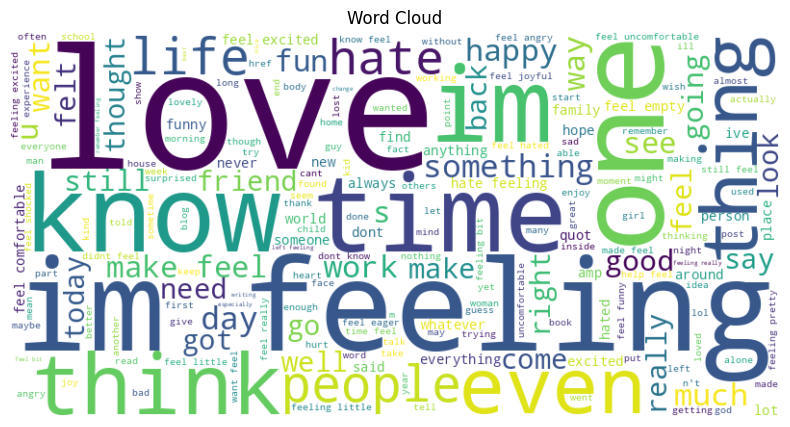

In [25]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df["processed_text"])

wordcloud = WordCloud(width=800,height=400,background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud")
plt.show()